# AGNDisk Demo

This notebook demonstrates how to use the `AGNDisk` class from `disktab.py` to generate Shakura-Sunyaev AGN disk profiles using Newton's method.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c

## Basic Usage

Create an `AGNDisk` object and set the required physical parameters:
- `M`: Central black hole mass
- `Mdot`: Mass accretion rate
- `alpha`: Shakura-Sunyaev viscosity parameter

In [2]:
# Create disk object
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = 1e21 * u.kg / u.s  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
disk.generate(rvals=np.logspace(1, 7, 200))

print(f"Gravitational radius: {disk.gRad.to(u.AU):.4f}")
print(f"Inner boundary (Rstar): {(disk.Rstar / disk.gRad).decompose():.1f} Rg")

Gravitational radius: 0.9871 AU
Inner boundary (Rstar): 6.0 Rg


/tmp/ipykernel_28899/2797889891.py:12: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=20, w=20): 40 rows [82, 122) around index 102 (R/Rg ≈ 11895.3) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  disk.generate(rvals=np.logspace(1, 7, 200))


In [3]:
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone,grad_T,grad_Sigma,grad_P,grad_P_raw,grad_Sigma_raw
0,1.476625e+12,1.000000e+01,344436.084407,5.701130e-05,3.819626e+06,258839.150165,4.031619e+09,1.043541e+14,229838.190410,344828.100643,Standard,0.357443,0.020960,1.464904,1.464904,0.020960
1,1.582782e+12,1.071891e+01,335993.946441,5.109848e-05,3.450268e+06,259849.837208,4.491569e+09,1.167134e+14,229503.991007,312392.756054,Standard,0.363947,-0.055481,1.477916,1.477916,-0.055481
2,1.696570e+12,1.148951e+01,327462.897056,4.686647e-05,3.111002e+06,257643.381394,4.942205e+09,1.273326e+14,231615.581271,276562.845865,Standard,0.375498,-0.193243,1.501032,1.501032,-0.193243
3,1.818538e+12,1.231551e+01,318924.841157,4.378485e-05,2.801163e+06,252934.027091,5.384373e+09,1.361891e+14,235745.309263,240370.233320,Standard,0.384772,-0.304023,1.519592,1.519592,-0.304023
4,1.949276e+12,1.320088e+01,310427.214758,4.152051e-05,2.519223e+06,246321.285931,5.819102e+09,1.433369e+14,241602.159259,205821.854793,Standard,0.392773,-0.393424,1.535600,1.535600,-0.393424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.118580e+18,7.575250e+06,42.613384,2.261124e-17,8.297039e-10,6057.582946,6.220773e+16,3.768285e+19,2.813188,1.000000,Self-Reg,0.746948,1.499852,2.999703,2.999703,1.499852
196,1.198997e+18,8.119845e+06,40.459934,1.835998e-17,6.737204e-10,6057.644257,6.903589e+16,4.181948e+19,2.534995,1.000000,Self-Reg,0.747103,1.499857,2.999713,2.999713,1.499857
197,1.285194e+18,8.703591e+06,38.414894,1.490802e-17,5.470612e-10,6057.703476,7.661350e+16,4.641018e+19,2.284311,1.000000,Self-Reg,0.747250,1.499862,2.999723,2.999723,1.499862
198,1.377588e+18,9.329304e+06,36.472848,1.210508e-17,4.442136e-10,6057.760673,8.502282e+16,5.150479e+19,2.058416,1.000000,Self-Reg,0.747389,1.499866,2.999733,2.999733,1.499866


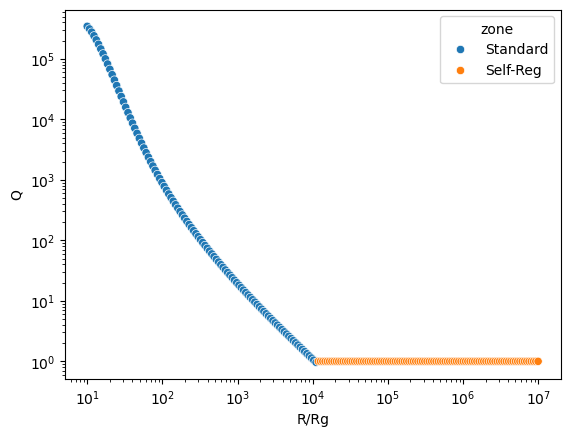

In [4]:
sns.scatterplot(data=disk.model, x="R/Rg", y="Q", hue="zone")
plt.xscale("log")
plt.yscale("log")

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1032: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


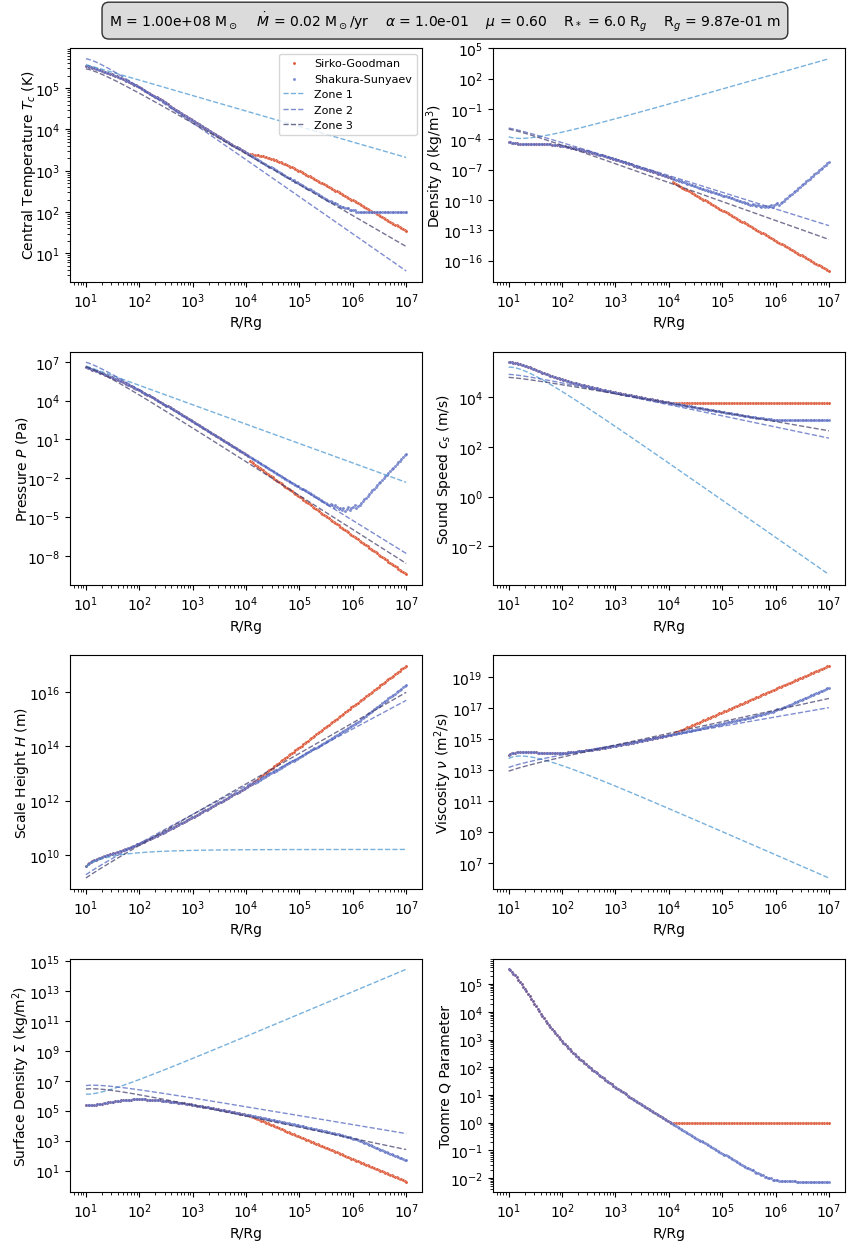

In [5]:
fig, axs = disk.layout(include_standard=True)

In [6]:
#fig.savefig("DiskModel.pdf")

## SpaceHub Unit Conversion

Convert the disk model to SpaceHub's native unit system for use with the N-body integrator.

SpaceHub uses:
- Mass: Solar masses (M☉)
- Length: AU
- Time: year/(2π), so that G = 1 and 1 year = 2π
- Temperature: Kelvin

In [7]:
# Convert to SpaceHub units
df_spacehub = disk.spacehub_pretab()

# Display first few rows
print("Disk model in SpaceHub units (M☉, AU, yr/2π):")
df_spacehub.head(10)

ValueError: spacehub_pretab requires at least 500 radial points, got 200. Increase the number of radii passed via rvals.

In [ ]:
# Verify unit conversions are correct
# Compare first row values between SI and SpaceHub units

AU_m = 1.495978707e11  # meters per AU
Msun_kg = 1.98847e30   # kg per solar mass
year_s = 365.25636042 * 24 * 3600
T_unit = year_s / (2 * np.pi)  # SpaceHub time unit in seconds

row_si = disk.model.iloc[0]
row_sh = df_spacehub.iloc[0]

print("Unit conversion verification (first row):")
print("=" * 60)
print(f"{'Quantity':<12} {'SI Value':<15} {'SpaceHub Value':<15} {'Expected':<15}")
print("-" * 60)
print(f"{'R':<12} {row_si['R']:<15.4e} {row_sh['R']:<15.4e} {row_si['R']/AU_m:<15.4e} (AU)")
print(f"{'H':<12} {row_si['H']:<15.4e} {row_sh['H']:<15.4e} {row_si['H']/AU_m:<15.4e} (AU)")
print(f"{'cs':<12} {row_si['cs']:<15.4e} {row_sh['cs']:<15.4e} {row_si['cs']*T_unit/AU_m:<15.4e} (AU/T)")
print(f"{'Tc':<12} {row_si['Tc']:<15.4e} {row_sh['Tc']:<15.4e} {row_si['Tc']:<15.4e} (K, unchanged)")
print(f"{'Q':<12} {row_si['Q']:<15.4e} {row_sh['Q']:<15.4e} {row_si['Q']:<15.4e} (dimensionless)")
print("=" * 60)
print("Conversions verified!" if np.isclose(row_sh['R'], row_si['R']/AU_m) else "ERROR in conversions!")

Unit conversion verification (first row):
Quantity     SI Value        SpaceHub Value  Expected       
------------------------------------------------------------
R            1.4766e+12      9.8706e+00      9.8706e+00      (AU)
H            3.7452e+11      2.5035e+00      2.5035e+00      (AU)
cs           2.4045e+07      8.0730e+02      8.0730e+02      (AU/T)
Tc           3.5733e+05      3.5733e+05      3.5733e+05      (K, unchanged)
Q            2.7644e+09      2.7644e+09      2.7644e+09      (dimensionless)
Conversions verified!
